In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('aug_train.csv')
print("حجم البيانات المستوردة:", df.shape)
df.head()

حجم البيانات المستوردة: (19158, 14)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [2]:
if 'enrollee_id' in df.columns:
    df.drop('enrollee_id', axis=1, inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print("عدد القيم المفقودة بعد التنظيف:")
print(df.isnull().sum())

عدد القيم المفقودة بعد التنظيف:
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64


/tmp/ipykernel_904/390153178.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_904/390153178.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [3]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("حجم بيانات التدريب بنجاح:", X_train.shape)

حجم بيانات التدريب بنجاح: (15326, 176)


In [4]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("دقة نموذج Logistic Regression:", accuracy_score(y_test, lr_preds))
print("دقة نموذج Random Forest:", accuracy_score(y_test, rf_preds))

print("\nتقرير الأداء التفصيلي لنموذج Random Forest:")
print(classification_report(y_test, rf_preds))

دقة نموذج Logistic Regression: 0.7774008350730689
دقة نموذج Random Forest: 0.7630480167014614

تقرير الأداء التفصيلي لنموذج Random Forest:
              precision    recall  f1-score   support

         0.0       0.82      0.88      0.85      2880
         1.0       0.53      0.39      0.45       952

    accuracy                           0.76      3832
   macro avg       0.67      0.64      0.65      3832
weighted avg       0.74      0.76      0.75      3832



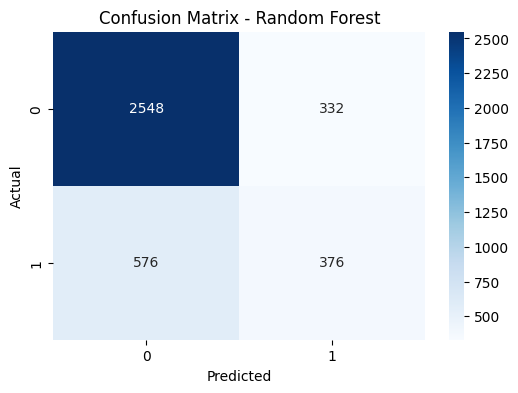

In [5]:
cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

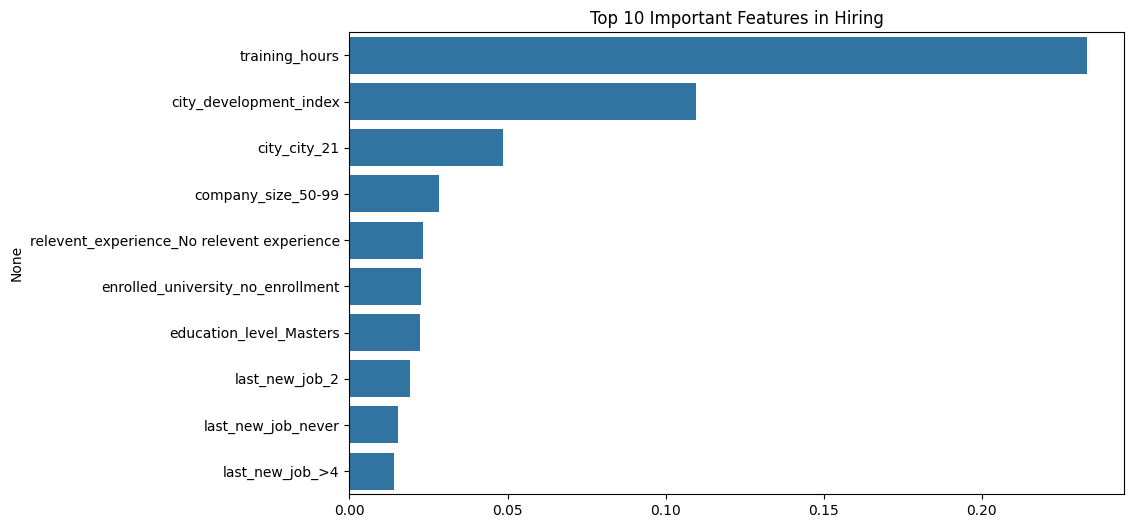

قائمة بأفضل 10 مرشحين يوصي النظام بتوظيفهم:
 Candidate_Index  Hiring_Probability
            2878                0.99
            3111                0.98
            6011                0.95
            1277                0.95
            5157                0.94
            2701                0.94
            5478                0.94
            1981                0.94
           12681                0.94
           18674                0.94


In [6]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Important Features in Hiring")
sns.barplot(x=importances[indices[:10]], y=X.columns[indices[:10]])
plt.show()

test_probabilities = rf_model.predict_proba(X_test)[:, 1]
ranking_df = pd.DataFrame({'Candidate_Index': X_test.index, 'Hiring_Probability': test_probabilities})
top_10_candidates = ranking_df.sort_values(by='Hiring_Probability', ascending=False).head(10)

print("قائمة بأفضل 10 مرشحين يوصي النظام بتوظيفهم:")
print(top_10_candidates.to_string(index=False))